# PADL coursework : Y3921738

In [ ]:
!pip uninstall -y gensim
!pip install gensim==4.3.2 numpy==1.25.2 scipy==1.10.1 --upgrade --force-reinstall

Found existing installation: gensim 4.3.2
Uninstalling gensim-4.3.2:
  Successfully uninstalled gensim-4.3.2
  Using cached gensim-4.3.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.3 kB)
  Using cached numpy-1.25.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
  Using cached scipy-1.10.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
  Using cached smart_open-7.1.0-py3-none-any.whl.metadata (24 kB)
  Using cached wrapt-1.17.2-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.4 kB)
Using cached gensim-4.3.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.7 MB)
Using cached numpy-1.25.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
Using cached scipy-1.10.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (34.1 MB)
Using cached smart_open-7.1.0-py3-none-any.whl (61 kB)
Using cached wrapt-1.17.2-c

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.model_selection import train_test_split
from scipy.stats import zscore

from sklearn.metrics import r2_score, accuracy_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

from gensim.models import Word2Vec

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from sklearn.ensemble import IsolationForest

import os
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from torch.utils.data import random_split
from torchvision import models
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit

from skimage.metrics import structural_similarity as ssim

PROJECT_DIRECTORY = '/content/drive/MyDrive/padl_ws/'
DATA_DIRECTORY = PROJECT_DIRECTORY + "data/"
MODEL_DIRECTORY = PROJECT_DIRECTORY + "models/"

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## Q1

### A

In [ ]:
# Get data from PADL-Q11-train.csv
data = np.loadtxt((DATA_DIRECTORY + '/PADL-Q11-train.csv'), delimiter=',', skiprows=1)
# Load header to get feature names
header = np.genfromtxt(DATA_DIRECTORY + '/PADL-Q11-train.csv', delimiter=',', max_rows=1, dtype=str)

# Split data into features and targets and feature names
X = data[:, :-1]
y = data[:, -1]
feature_names = header[:-1]

# Create model
model_1a = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('reg', LinearRegression())
])

# Train model on training data
model_1a.fit(X, y)

# Get coefficients
poly_feat_names = model_1a.named_steps['poly'].get_feature_names_out(input_features=feature_names)
coefs = np.hstack((model_1a.named_steps['reg'].intercept_, model_1a.named_steps['reg'].coef_))

print("Coefficients:")
print(f"{'Feature':>15s} | {'Coefficient':>12s}")
print("-" * 30)
print(f"{'(intercept)':>15s} | {coefs[0]:>12.6f}")
for name, coef in zip(poly_feat_names, coefs[1:]):
    print(f"{name:>15s} | {coef:>12.6f}")

Coefficients:
        Feature |  Coefficient
------------------------------
    (intercept) |     0.063794
              1 |     0.000000
             X1 |     0.356364
             X2 |     0.886995
             X3 |     0.168685
             X4 |     0.388997
             X5 |     0.260931
           X1^2 |    -0.450897
          X1 X2 |     1.922191
          X1 X3 |     2.376696
          X1 X4 |    -0.960790
          X1 X5 |     0.511939
           X2^2 |    -2.000182
          X2 X3 |    -4.981602
          X2 X4 |     2.046214
          X2 X5 |    -1.136540
           X3^2 |    -3.095155
          X3 X4 |     2.530674
          X3 X5 |    -1.388727
           X4^2 |    -0.511807
          X4 X5 |     0.546239
           X5^2 |    -0.134698


In [ ]:
unseen = np.loadtxt("PADL-Q11-unseen.csv", delimiter=',', skiprows=1)
unseen_X = unseen[:, :-1]
unseen_y = unseen[:, -1]

y_pred = model_1a.predict(unseen_X)

print("R²:", r2_score(unseen_y, y_pred))

### B

In [ ]:
# Get data from PADL-Q12-train.csv
data = np.loadtxt((DATA_DIRECTORY + '/PADL-Q12-train.csv'), delimiter=',', skiprows=1)

# Split data into X and y
X = data[:, :-1]
y = data[:, -1]

# # Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

# Train a linear regression model to act as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)
r2_lr = r2_score(y_val, y_pred_lr)

# Display the coefficients and R² for the generic Linear Regression model
print('Generic Linear Regression')
print(f"Coefficients: {lr_model.coef_}\nSum |coefficients|: {np.sum(np.abs(lr_model.coef_))}")
print(f"R²: {r2_lr:.4f}")

# Now with regularised models
# Define paramter space
alphas = np.logspace(-4, 2, 1000)
r2_threshold = 0.9 * r2_lr

# Initialise optimiation values
best_model = None
best_model_type = ''
best_alpha = None
best_r2 = -np.inf
lowest_coef_sum = np.inf

for alpha in alphas:
    # test L1 and L2 regression
    for model_type, model_class in [('Ridge', Ridge), ('Lasso', Lasso)]:
        model = model_class(alpha=alpha, max_iter=10000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        r2 = r2_score(y_val, y_pred)

        if r2 >= r2_threshold:
            coef_sum = np.sum(np.abs(model.coef_))
            if coef_sum < lowest_coef_sum:
                best_model = model
                best_model_type = model_type
                best_alpha = alpha
                best_r2 = r2
                lowest_coef_sum = coef_sum

print()
print('Regularised Model')
print(f"Model type: {best_model_type}")
print(f"Alpha: {best_alpha}")
print("Coefficients:", best_model.coef_)
print(f"Sum |coefficients|: {lowest_coef_sum:.4f}")
print(f"R²: {best_r2:.4f}")


Generic Linear Regression
Coefficients: [0.06072363 3.06654222 0.9950157  0.08221147]
Sum |coefficients|: 4.2044930268031635
R²: 0.9590

Regularised Model
Model type: Lasso
Alpha: 20.10496416260497
Coefficients: [0.06029225 0.66131033 0.8998179  0.        ]
Sum |coefficients|: 1.6214
R²: 0.8651


In [ ]:
# Load unseen data
unseen_data = np.loadtxt('PADL-Q12-unseen.csv', delimiter=',', skiprows=1)
X_unseen = unseen_data[:, :-1]
y_unseen = unseen_data[:, -1]

# Predict using the best regularised model
y_unseen_pred = best_model.predict(X_unseen)

# Predict with Linear Regression on unseen data
y_unseen_pred_lr = lr_model.predict(X_unseen)
r2_unseen_lr = r2_score(y_unseen, y_unseen_pred_lr)

# Predict with regularised model
y_unseen_pred_reg = best_model.predict(X_unseen)
r2_unseen_reg = r2_score(y_unseen, y_unseen_pred_reg)

# Report results
print("\n--- Final Report on Unseen Data ---")

print("\nGeneric Linear Regression:")
print(f"R² (unseen): {r2_unseen_lr:.4f}")
print(f"Coefficients: {lr_model.coef_}")
print(f"Sum |coefficients|: {np.sum(np.abs(lr_model.coef_)):.4f}")

print(f"\n{best_model_type} Regularised Regression (α={best_alpha:.4g}):")
print(f"R² (unseen): {r2_unseen_reg:.4f}")
print(f"Coefficients: {best_model.coef_}")
print(f"Sum |coefficients|: {lowest_coef_sum:.4f}")

### C

In [ ]:
# Get data from PADL-Q13-train.csv
data = np.loadtxt((DATA_DIRECTORY + '/PADL-Q13-train.csv'), delimiter=',', skiprows=1)

# Split data into X and y
X = data[:, :-1]
y = data[:, -1]

# Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3)

# Train a linear regression model to act as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)
r2_lr = r2_score(y_val, y_pred_lr)

# Compute Z-scores for X_train
z_scores = np.abs(zscore(X_train))
threshold = 3

mask = (z_scores < threshold).all(axis=1)

X_train = X_train[mask]
y_train = y_train[mask]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Use RFE for feature selection
rfe = RFE(lr_model, n_features_to_select=4)
X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_val_rfe = rfe.transform(X_val_scaled)

# Train model on selected features
preprocessing_model = LinearRegression()
preprocessing_model.fit(X_train_rfe, y_train)
y_pred_pca = preprocessing_model.predict(X_val_rfe)
r2_preprocessing = r2_score(y_val, y_pred_pca)

# Display results
print(f"R² without preprocessing: {r2_lr}")
print(f"R² with preprocessing: {r2_preprocessing}")
print(f"Improvement: {r2_preprocessing - r2_lr}")


R² without preprocessing: 0.9671441268673227
R² with preprocessing: 0.9685584684361149
Improvement: 0.0014143415687922767


My preprocessing steps dont always show an improvement, due to different random initialisations, but there is roughly a 0.0014 percentage increase from unpreprocessed linear regression

The

In [ ]:
# Load unseen data
unseen_data = np.loadtxt('PADL-Q13-unseen.csv', delimiter=',', skiprows=1)
X_unseen = unseen_data[:, :-1]
y_unseen = unseen_data[:, -1]

y_unseen_pred_baseline = lr_model.predict(X_unseen)
y_unseen_pred_rfe = preprocessing_model.predict(pca.transform(X_unseen))

r2_unseen_baseline = r2_score(y_unseen, y_unseen_pred_baseline)
r2_unseen_rfe = r2_score(y_unseen, y_unseen_pred_rfe)

# Baseline
print(f"Baseline R²: {r2_unseen_baseline:.4f}")
print(f"R² with preprocessing: {r2_unseen_rfe:.4f}")

## Q2

### A

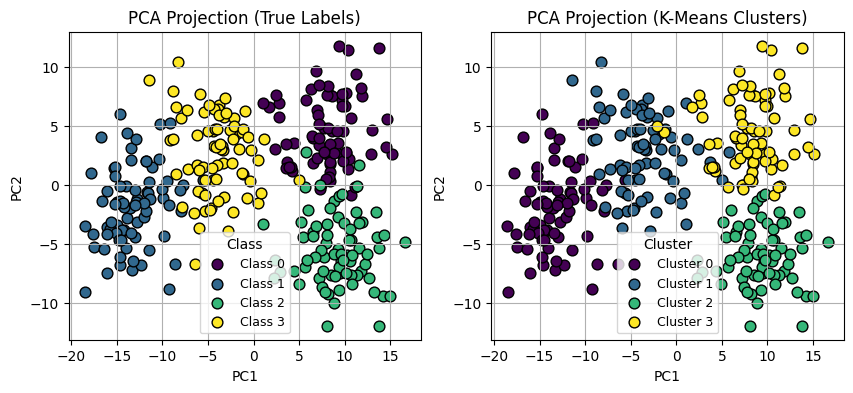

In [ ]:
# Load data from PADL-Q2.csv
data = np.loadtxt((DATA_DIRECTORY + 'PADL-Q2.csv'), delimiter=',', skiprows=1)

# Extract into features and labels
X = data[:, :-1]
Y = data[:, -1]

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define number of clusters
num_clusters = len(np.unique(Y))

# K-means on original data
kmeans = KMeans(n_clusters=num_clusters)
Y_kmeans = kmeans.fit_predict(X_scaled)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Colour map
cmap = plt.get_cmap('viridis', num_clusters)

# Create figure
plt.figure(figsize=(10,4))

# Plot 1: PCA with true labels
plt.subplot(1, 2, 1)
for i, label in enumerate(np.unique(Y)):
    color = cmap(i)
    plt.scatter(X_pca[Y == label, 0], X_pca[Y == label, 1],
                label=f'Class {int(label)}', c=[color], edgecolor='k', s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (True Labels)')
plt.legend(title='Class', fontsize=9)
plt.grid(True)

# Plot 2: PCA with K-means clusters
plt.subplot(1, 2, 2)
for i in range(num_clusters):
    color = cmap(i)
    plt.scatter(X_pca[Y_kmeans == i, 0], X_pca[Y_kmeans == i, 1],
                label=f'Cluster {i}', c=[color], edgecolor='k', s=60, marker='o')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (K-Means Clusters)')
plt.legend(title='Cluster', fontsize=9)
plt.grid(True)

### B

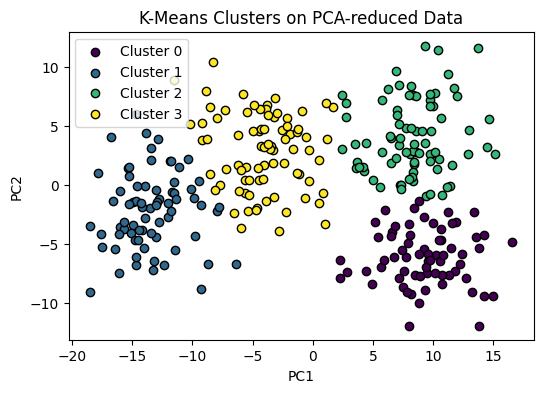

In [ ]:
# Apply K-means to PCA data
kmeans_pca = KMeans(n_clusters=num_clusters)
Y_kmeans_pca = kmeans_pca.fit_predict(X_pca)

# Plot predictions from kmeans after PCA
plt.figure(figsize=(6, 4))

for cluster in range(num_clusters):
    plt.scatter(X_pca[Y_kmeans_pca == cluster, 0], X_pca[Y_kmeans_pca == cluster, 1],
                label=f"Cluster {cluster}",c=[cmap(cluster)], edgecolor="k")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA-reduced Data")
plt.legend()
plt.show()

### C

In [ ]:
def clustering_accuracy(y_true, y_pred):
    # Build confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Solve the assignment problem (Hungarian algorithm)
    row_ind, col_ind = linear_sum_assignment(-cm)
    # Map predicted labels to best-matching true labels
    optimal_mapping = {old: new for old, new in zip(col_ind, row_ind)}
    mapped_preds = np.vectorize(optimal_mapping.get)(y_pred)
    # Return accuracy
    return accuracy_score(y_true, mapped_preds)

acc_full = clustering_accuracy(Y, Y_kmeans)
acc_pca = clustering_accuracy(Y, Y_kmeans_pca)
pca_variance = np.sum(pca.explained_variance_ratio_) * 100

print(f"Accuracy with all five features: {acc_full:.4f}")
print(f"Accuracy with PCA-reduced features: {acc_pca:.4f}")
print(f"Percentage of variance explained by PCA: {pca_variance:.2f}%")
print(f"Accuracy drop: {acc_full - acc_pca:.2%}")

Accuracy with all five features: 0.9533
Accuracy with PCA-reduced features: 0.9400
Percentage of variance explained by PCA: 77.43%
Accuracy drop: 1.33%


## Q3

### A

In [ ]:
# Load data from PADL-Q3.txt
with open((DATA_DIRECTORY + 'PADL-Q3.txt'), 'r') as f:
    sentences = [line.strip().split() for line in f]

# Train a Skip-gram Word2Vec model
skip_gram_model = Word2Vec(sentences=sentences, min_count=1 ,sg=1)
word_embeddings = skip_gram_model.wv

# Cosine similarities betweeen node 5 and nodes 21 - 30
print("Similarities with node 5:")
for i in range(21, 31):
    try:
        sim = word_embeddings.similarity("5", str(i))
        print(f"Node 5 <-> Node {i}: {sim:.4f}")
    except KeyError:
        print(f"Node {i} not in vocabulary.")


Similarities with node 5:
Node 5 <-> Node 21: 0.2110
Node 5 <-> Node 22: 0.1284
Node 5 <-> Node 23: 0.3160
Node 5 <-> Node 24: 0.2931
Node 5 <-> Node 25: 0.1998
Node 5 <-> Node 26: 0.1835
Node 5 <-> Node 27: 0.2863
Node 5 <-> Node 28: 0.2574
Node 5 <-> Node 29: 0.1801
Node 5 <-> Node 30: 0.2040


### B

In [ ]:
# Get all node IDs from the model
node_ids = skip_gram_model.wv.index_to_key

# Build similarity matrix
output_lines = []
for node in node_ids:
    similarities = []
    for other in node_ids:
        if node != other:
            sim = word_embeddings.similarity(node, other)
            similarities.append((other, sim))

    # Sort by similarity descending
    similarities.sort(key=lambda x: x[1], reverse=True)
    sorted_node_ids = [node_id for node_id, _ in similarities]

    # Append as space-separated line
    output_lines.append(" ".join(sorted_node_ids))

# Save to result file
result_path = PROJECT_DIRECTORY + "PADL-Q3-result.txt"
with open(result_path, "w") as f:
    f.write("\n".join(output_lines))

print(f"Result saved to {result_path}")


Result saved to /content/drive/MyDrive/padl_ws/PADL-Q3-result.txt


## Q4

### A

For this problem I have chosen a simple MLP enhanced with attention and residual connections. I chose a 5 layer MLP with each layer being 64 nodes wide except the output layer, which reduces the output to a single prediction of wasit cicrumference. Through testing I found this to create the most consistent loss graphs. The dataset provided is small with only 5 features and 1800 datapoints so larger more complex models would likely overfit. Attention was used to give more weight to more important features like height and weight. Residual connections were implemented as an attempt to increase performance, which they did so they were kept. It was also found that both batchnorm and layernorm increased performance so within they were implented into the residual blocks.

### B

#### Data

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data --------------------------------------------------------------------
data = np.genfromtxt((DATA_DIRECTORY + 'body_measurements.csv'),
                     delimiter=',', skip_header=1)
print(data.shape)

# Filter bad data samples ------------------------------------------------------
# Filter out NaN rows
valid_rows = ~np.isnan(data).any(axis=1)
data_filtered = data[valid_rows]

# Filter out rows with outlier waist values using the IQR method
waist = data_filtered[:, -1]
Q1 = np.percentile(waist, 25)
Q3 = np.percentile(waist, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

inlier_mask = (waist >= lower_bound) & (waist <= upper_bound)
data_clean = data_filtered[inlier_mask]

# Filter out rows with outlier features using isolation forest
iso = IsolationForest(contamination=0.03)
outliers = iso.fit_predict(data_clean[:, 1:-1])

# Keep only inliers
mask = outliers == 1
data_clean = data_clean[mask]

# Data splits ------------------------------------------------------------------
X_train_val, X_test, y_train_val, y_test = train_test_split(
    data_clean[:, :-1], data_clean[:, -1], test_size=0.20
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2
)

# Standardize numeric features -------------------------------------------------
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Convert to PyTorch tensors ---------------------------------------------------
X_train_tensor = torch.tensor(X_train_poly, dtype=torch.float32)

print(X_train_tensor.shape)

X_val_tensor = torch.tensor(X_val_poly, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_poly, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)


(1800, 6)
torch.Size([1088, 20])


#### Model

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, size, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(size, size),
            nn.BatchNorm1d(size),
            nn.LayerNorm(size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return x + self.block(x)

class WaistPredictor(nn.Module):
    def __init__(self, input_size, dropout=0.1):
        super().__init__()
        hidden_size = 64

        self.attention = nn.Sequential(
            nn.Linear(input_size, input_size),
            nn.Sigmoid()
        )

        self.input_layer = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.res_block1 = ResidualBlock(hidden_size, dropout=dropout)
        self.res_block2 = ResidualBlock(hidden_size, dropout=dropout)
        self.res_block3 = ResidualBlock(hidden_size, dropout=dropout)

        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, x):
        attention_weights = self.attention(x)
        x = x * attention_weights
        x = self.input_layer(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.res_block3(x)
        x = self.output_layer(x)
        return x


# Define model
waist_predictor = WaistPredictor(input_size=X_train_tensor.shape[1]).to(device)

#### Training

In [ ]:
loss_function = nn.L1Loss()

optimiser = optim.AdamW(waist_predictor.parameters(), lr = 5e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.1, patience=10, min_lr=1e-6)

epochs = 300
batch_size = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 100
lr_changes = []

# Training loop
waist_predictor.train()
for epoch in range(epochs):
    total_train_loss = 0.0
    total_val_loss = 0.0
    waist_predictor.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimiser.zero_grad()
        predictions = waist_predictor(batch_X)
        loss = loss_function(predictions, batch_y)
        loss.backward()
        optimiser.step()
        total_train_loss += loss.item() * batch_X.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Validation
    waist_predictor.eval()
    total_val_loss = 0.0
    with torch.no_grad():
      for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        val_preds = waist_predictor(batch_X)
        val_loss = loss_function(val_preds, batch_y).item()
        total_val_loss += val_loss * batch_X.size(0)

    avg_val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    current_lr = scheduler.optimizer.param_groups[0]['lr']
    lr_changes.append(current_lr)

    if (epoch+1)%10 == 0:
        print(f"Epoch {epoch+1}, Train MAE: {avg_train_loss:.2f}, Train MAE: Val MAE: {avg_val_loss:.2f}, lr {current_lr}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(waist_predictor.state_dict(), MODEL_DIRECTORY + 'waist_predictor_temp.pth')


Epoch 10, Train MAE: 392.07, Train MAE: Val MAE: 326.23, lr 0.005
Epoch 20, Train MAE: 41.35, Train MAE: Val MAE: 35.12, lr 0.005
Epoch 30, Train MAE: 36.65, Train MAE: Val MAE: 34.96, lr 0.005
Epoch 40, Train MAE: 35.41, Train MAE: Val MAE: 31.88, lr 0.005
Epoch 50, Train MAE: 35.09, Train MAE: Val MAE: 32.26, lr 0.005
Epoch 60, Train MAE: 33.60, Train MAE: Val MAE: 32.13, lr 0.0005
Epoch 70, Train MAE: 34.51, Train MAE: Val MAE: 32.26, lr 5e-05
Epoch 80, Train MAE: 32.41, Train MAE: Val MAE: 32.26, lr 5e-06
Epoch 90, Train MAE: 35.57, Train MAE: Val MAE: 32.27, lr 1e-06
Epoch 100, Train MAE: 33.58, Train MAE: Val MAE: 32.24, lr 1e-06
Epoch 110, Train MAE: 33.77, Train MAE: Val MAE: 32.28, lr 1e-06
Epoch 120, Train MAE: 34.12, Train MAE: Val MAE: 32.23, lr 1e-06
Epoch 130, Train MAE: 34.34, Train MAE: Val MAE: 32.25, lr 1e-06
Epoch 140, Train MAE: 34.41, Train MAE: Val MAE: 32.24, lr 1e-06
Epoch 150, Train MAE: 35.47, Train MAE: Val MAE: 32.24, lr 1e-06
Epoch 160, Train MAE: 34.12, Tr

#### Testing

MAE on the test set: 31.43
Model size: 76550 bytes
Model size: 0.07300376892089844 MB


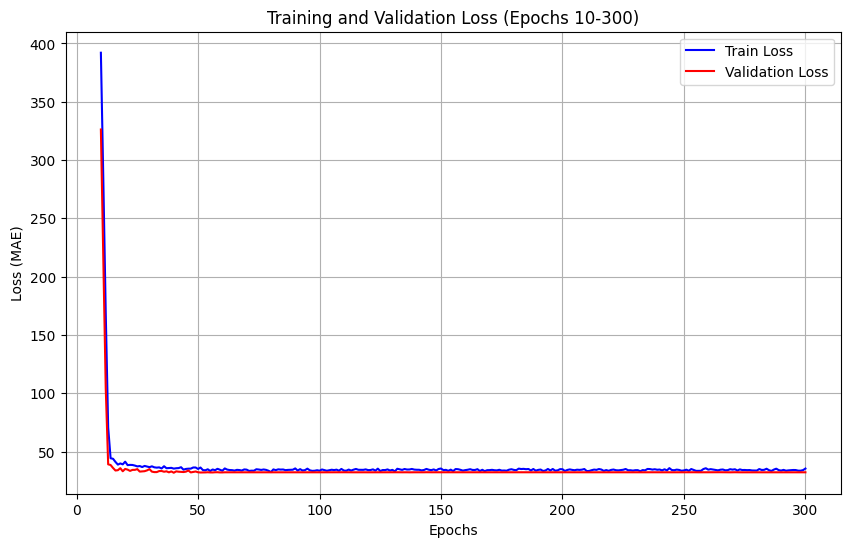

In [ ]:
waist_predictor.load_state_dict(torch.load(MODEL_DIRECTORY + 'waist_predictor_temp.pth'))

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Switch to evaluation mode
waist_predictor.eval()
total_test_loss = 0.0
with torch.no_grad():
  for batch_X, batch_y in test_loader:
    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
    y_test_pred = waist_predictor(batch_X)
    test_loss = loss_function(y_test_pred, batch_y).item()
    total_test_loss += test_loss * batch_X.size(0)

avg_test_loss = total_test_loss / len(test_loader.dataset)
print(f"MAE on the test set: {avg_test_loss:.2f}")

file_size = os.path.getsize(MODEL_DIRECTORY + 'waist_predictor_temp.pth')
print(f"Model size: {file_size} bytes")
print(f"Model size: {file_size / (1024**2)} MB") # in MB

# Plot training and validation loss from epoch 100 to 1000
start_epoch = 10
end_epoch = len(train_losses)

plt.figure(figsize=(10, 6))
plt.plot(range(start_epoch, end_epoch + 1), train_losses[start_epoch - 1:end_epoch], label="Train Loss", color='blue')
plt.plot(range(start_epoch, end_epoch + 1), val_losses[start_epoch - 1:end_epoch], label="Validation Loss", color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss (MAE)')
plt.title(f'Training and Validation Loss (Epochs {start_epoch}-{end_epoch})')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# torch.save(waist_predictor.state_dict(), MODEL_DIRECTORY + "/waist_predictor.pth")

## Q5

### A

Architecture:
I have implemented a slighlty adjusted version of EfficientNetB0 without pretrained weights, as it remains one of the best convolution based architectures for image classification, while also being small and efficient. The final classification head has been modified in to output 3 classes rather than 1000, and the weights have been initialised randomly to conform with the no pretrained weights restriction. Transformers weren't considered as the amount of data was small and trasnfer learning was not permitted.

EfficientNetB0 Summary:
- Stem: 3×3 Conv with 32 filters  
- MBConv Blocks: A series of mobile inverted bottleneck (MBConv) blocks with squeeze-and-excitation (SE), including:
  - MBConv1 (expansion factor 1) and MBConv6 (expansion factor 6)
  - Varying kernel sizes (3x3, 5x5)
  - Increasing filter sizes and decreasing resolution across stages
- Head: 1×1 Conv with 1280 filters  
- Classifier: was changed to a 256 dim linear layer, batchnorm and relu and a final linear layer outputting 3 classes.

### B

#### Data

In [ ]:
DATASET_PATH = DATA_DIRECTORY + 'garment_images'
LABELS_CSV = DATA_DIRECTORY + 'garment_images/train_labels.csv'
num_workers = 4
batch_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

base_transform = transforms.Compose([
    transforms.Resize(256),
])

final_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

augmented_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    final_transform,
])

class GarmentImageDataset(Dataset):
    def __init__(self, root_dir, labels_csv, transform=None):
        self.root_dir = root_dir
        self.labels_df = pd.read_csv(labels_csv)
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        filename = self.labels_df.iloc[idx, 0]
        label = int(self.labels_df.iloc[idx, 1])

        img_path = os.path.join(self.root_dir, str(label), filename)

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

class AugmentedDataset(Dataset):
    def __init__(self, subset, original_transform, augmented_transform, n_augmentations=0):
        self.subset = subset
        self.original_transform = original_transform
        self.augmented_transform = augmented_transform
        self.n_augmentations = n_augmentations
        self.expanded_indices = []
        for idx in range(len(subset)):
            self.expanded_indices.append((idx, 'original'))
            for _ in range(n_augmentations):
                self.expanded_indices.append((idx, 'augmented'))

    def __len__(self):
        return len(self.expanded_indices)

    def __getitem__(self, idx):
        base_idx, mode = self.expanded_indices[idx]
        image, label = self.subset[base_idx]

        if mode == 'original':
            image = self.original_transform(image)
        else:
            image = self.augmented_transform(image)

        return image, label


# Original dataset without transform
base_dataset = GarmentImageDataset(DATASET_PATH, LABELS_CSV)

print(len(base_dataset))

# Load labels
labels_df = pd.read_csv(LABELS_CSV)
labels = labels_df.iloc[:, 1].tolist()  # assuming second column is labels
labels = np.array(labels)

# Define the stratified splitter
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3)
for train_index, temp_index in sss1.split(np.zeros(len(labels)), labels):
    pass

temp_labels = labels[temp_index]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.66)
for val_index, test_index in sss2.split(np.zeros(len(temp_labels)), temp_labels):
    pass

# Get actual indices for subsets
val_index = np.array(temp_index)[val_index]
test_index = np.array(temp_index)[test_index]

# Create subsets
train_subset = torch.utils.data.Subset(base_dataset, train_index)
val_subset = torch.utils.data.Subset(base_dataset, val_index)
test_subset = torch.utils.data.Subset(base_dataset, test_index)

# Wrap train subset with a transform
train_dataset = AugmentedDataset(train_subset, final_transform, augmented_transform, n_augmentations=3)
val_dataset = AugmentedDataset(val_subset, final_transform, final_transform, n_augmentations=0)
test_dataset = AugmentedDataset(test_subset, final_transform, final_transform, n_augmentations=0)

# Create dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

# Get labels for train subset only
train_labels = labels[train_index]
label_counts = Counter(train_labels)
total_samples = len(train_labels)
num_classes = len(label_counts)

class_weights = []
for label in sorted(label_counts.keys()):
    count = label_counts[label]
    weight = total_samples / (num_classes * count) if count > 0 else 0.0
    class_weights.append(weight)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print(class_weights_tensor)


cuda
2626
Train size: 7352
Validation size: 267
Test size: 521
tensor([0.8545, 0.9648, 1.2606])


#### Model

In [ ]:
# Instantiate model
fashion_classifier = models.efficientnet_b0(weights=None)
fashion_classifier.classifier = nn.Sequential(
    nn.Linear(fashion_classifier.classifier[1].in_features, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 3)  # output 3 classes
)

fashion_classifier.to(device)
print()

#### Training

In [ ]:
# Hyperparameters
learning_rate = 3e-4
epochs = 30
weight_decay = 3e-3
best_val_loss = float('inf')

criterion = nn.CrossEntropyLoss(class_weights_tensor.to(device))
optimiser = optim.AdamW(fashion_classifier.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=5, min_lr=1e-6)

# Lists to store loss and accuracy values for plotting
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training loop
fashion_classifier.train()
correct, total = 0, 0

# Training and validation loop
for epoch in range(epochs):

    # Train the model
    fashion_classifier.train()
    train_correct, train_total = 0, 0
    running_loss = 0.0
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimiser.zero_grad()

        outputs = fashion_classifier(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimiser.step()

        running_loss += loss.item()
        train_total += labels.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / train_total
    avg_train_loss = running_loss / len(train_dataloader)

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%", end='')

    # Validation Loop
    fashion_classifier.eval()
    val_correct, val_total = 0, 0
    val_loss_total = 0.0
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = fashion_classifier(images)
            loss = criterion(outputs, labels)
            val_loss_total += loss.item()

            val_total += labels.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total
    avg_val_loss = val_loss_total / len(val_dataloader)

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step(avg_val_loss)

    print(f" - Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(fashion_classifier.state_dict(), MODEL_DIRECTORY + 'fashion_classifier_temp.pth')
        print("Best model saved!")

Epoch [1/30] - Train Loss: 0.7567, Train Accuracy: 60.57% - Validation Loss: 0.4463, Validation Accuracy: 80.52%
Best model saved!
Epoch [2/30] - Train Loss: 0.3729, Train Accuracy: 84.15% - Validation Loss: 0.3352, Validation Accuracy: 86.14%
Best model saved!
Epoch [3/30] - Train Loss: 0.2355, Train Accuracy: 91.20% - Validation Loss: 0.1277, Validation Accuracy: 92.88%
Best model saved!
Epoch [4/30] - Train Loss: 0.1775, Train Accuracy: 93.13% - Validation Loss: 0.1170, Validation Accuracy: 94.76%
Best model saved!
Epoch [5/30] - Train Loss: 0.1475, Train Accuracy: 94.45% - Validation Loss: 0.1298, Validation Accuracy: 95.51%
Epoch [6/30] - Train Loss: 0.1225, Train Accuracy: 95.66% - Validation Loss: 0.1166, Validation Accuracy: 95.13%
Best model saved!
Epoch [7/30] - Train Loss: 0.1023, Train Accuracy: 96.10% - Validation Loss: 0.0822, Validation Accuracy: 96.25%
Best model saved!
Epoch [8/30] - Train Loss: 0.0936, Train Accuracy: 96.84% - Validation Loss: 0.0928, Validation Accur

KeyboardInterrupt: 

#### Eval

Test Loss: 0.1706, Test Accuracy: 93.47%
Model size: 17655556 bytes
Model size: 16.837650299072266 MB


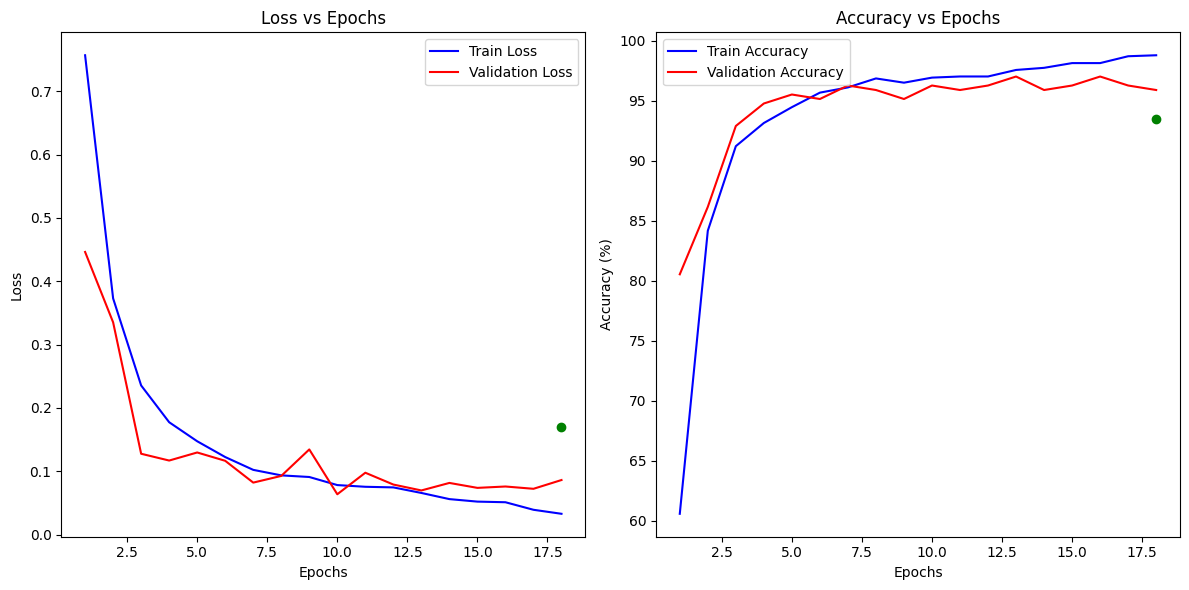

In [ ]:
fashion_classifier.load_state_dict(torch.load(MODEL_DIRECTORY + 'fashion_classifier_temp.pth'))
fashion_classifier.eval()
test_correct, test_total = 0, 0
test_loss = 0.0
with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)

        outputs = fashion_classifier(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total
average_test_loss = test_loss / len(test_dataloader)


print(f"Test Loss: {average_test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

file_size = os.path.getsize(MODEL_DIRECTORY + 'fashion_classifier_temp.pth')
print(f"Model size: {file_size} bytes")
print(f"Model size: {file_size / (1024**2)} MB") # in MB

# Plot Loss vs Epochs
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", color="blue")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", color="red")
plt.plot(len(train_losses), average_test_loss, 'go')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()

# Plot Accuracy vs Epochs
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label="Train Accuracy", color="blue")
plt.plot(range(1, len(val_losses) + 1), val_accuracies, label="Validation Accuracy", color="red")
plt.plot(len(train_accuracies), test_accuracy, 'go')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Epochs")
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

In [ ]:
# torch.save(fashion_classifier.state_dict(), MODEL_DIRECTORY + "/fashion_classifier.pth")

## Q6

### Code

#### Data

In [ ]:
dataset_path = DATA_DIRECTORY + "/face_images"

class FaceDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform or transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((192, 160)),
            transforms.ToTensor(),
        ])
        self.image_paths = [os.path.join(data_dir, fname) for fname in os.listdir(data_dir)]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path)
        if self.transform:
            image = self.transform(image)
        return image

# Load the full dataset
dataset = FaceDataset(data_dir=dataset_path)

#### Autoencoder and Functions

In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.convolutions = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),  # 192x160 → 96x80
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 96x80 → 48x40
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  # 48x40 → 24x20
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),  # 24x20 → 12x10
            nn.ReLU(),
        )
        self.fc = nn.Linear(256 * 12 * 10, 32)

    def forward(self, x):
        x = self.convolutions(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(32, 256 * 12 * 10)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 12x10 → 24x20
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 24x20 → 48x40
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 48x40 → 96x80
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),  # 96x80 → 192x160
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), 256, 12, 10)
        return self.deconv(x)

def ssim_score(image1, image2):
    image1 = image1.squeeze().detach().cpu().numpy()
    image2 = image2.squeeze().detach().cpu().numpy()
    return ssim(image1, image2, data_range=1.0)

def plot_images(original, reconstructed):
    # Ensure the image is in the correct range [0, 1]
    reconstructed = torch.clamp(reconstructed, 0, 1)

    # Convert to NumPy and squeeze batch dimension
    original = original.squeeze().cpu().detach().numpy()
    reconstructed = reconstructed.squeeze().cpu().detach().numpy()

    # Plotting the original and reconstructed images
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(reconstructed, cmap='gray')
    axes[1].set_title('Reconstructed Image')
    axes[1].axis('off')

    plt.show()

# Create the Encoder and Decoder
encoder = Encoder()
decoder = Decoder()

#### Training

In [ ]:
# Define hyperparameters
learning_rate = 1e-3
batch_size = 64
epochs = 30

# Create dataloaders
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

optimiser = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=learning_rate)

loss_fn = nn.MSELoss()

# Some training variables
train_losses = []
train_ssims = []
best_ssim = 0.0
temp_model_path = MODEL_DIRECTORY + "autoencoder_temp.pth"

# Training loop
for epoch in range(epochs):
    encoder.train()
    decoder.train()

    running_loss = 0.0
    running_ssim = 0.0

    # Training loop
    for i, images in enumerate(train_loader):
        optimiser.zero_grad()
        latents = encoder(images)
        reconstructed_images = decoder(latents)

        loss = loss_fn(reconstructed_images, images)
        ssim_value = ssim_score(reconstructed_images, images)

        loss.backward()
        optimiser.step()

        running_loss += loss.item()
        running_ssim += ssim_value

    avg_loss = running_loss / len(train_loader)
    avg_ssim = running_ssim / len(train_loader)

    # Print training statistics
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, SSIM: {avg_ssim:.4f}")


    # Save best model based on SSIM
    if avg_ssim > best_ssim:
      best_ssim = avg_ssim
      torch.save({
          'encoder_state_dict': encoder.state_dict(),
          'decoder_state_dict': decoder.state_dict(),
      }, temp_model_path)
      print("Best model saved!")

    # Append losses and ssims for visualisation
    train_losses.append(avg_loss)
    train_ssims.append(avg_ssim)

Epoch [1/30], Loss: 0.0567, SSIM: 0.3326
Best model saved!
Epoch [2/30], Loss: 0.0246, SSIM: 0.7164
Best model saved!
Epoch [3/30], Loss: 0.0203, SSIM: 0.7606
Best model saved!
Epoch [4/30], Loss: 0.0179, SSIM: 0.7859
Best model saved!
Epoch [5/30], Loss: 0.0164, SSIM: 0.8079
Best model saved!
Epoch [6/30], Loss: 0.0148, SSIM: 0.8249
Best model saved!
Epoch [7/30], Loss: 0.0130, SSIM: 0.8474
Best model saved!
Epoch [8/30], Loss: 0.0110, SSIM: 0.8667
Best model saved!
Epoch [9/30], Loss: 0.0087, SSIM: 0.8889
Best model saved!
Epoch [10/30], Loss: 0.0072, SSIM: 0.9038
Best model saved!
Epoch [11/30], Loss: 0.0065, SSIM: 0.9132
Best model saved!
Epoch [12/30], Loss: 0.0059, SSIM: 0.9191
Best model saved!
Epoch [13/30], Loss: 0.0054, SSIM: 0.9271
Best model saved!
Epoch [14/30], Loss: 0.0048, SSIM: 0.9348
Best model saved!
Epoch [15/30], Loss: 0.0043, SSIM: 0.9403
Best model saved!
Epoch [16/30], Loss: 0.0045, SSIM: 0.9401
Epoch [17/30], Loss: 0.0038, SSIM: 0.9479
Best model saved!
Epoch [

#### Training graph

Total size: 12.88 MiB


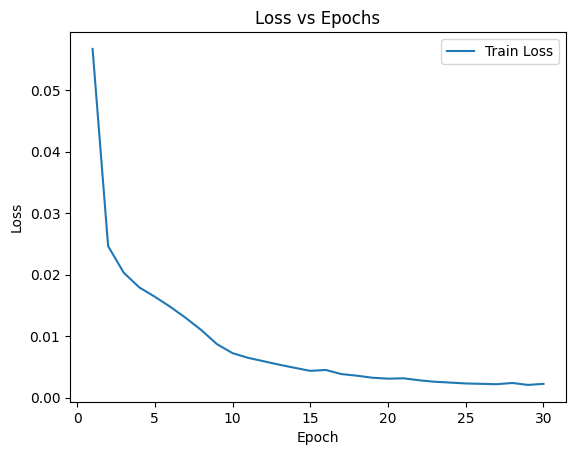

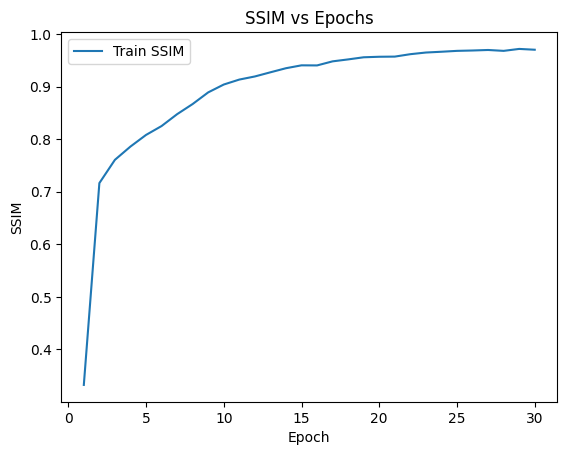

In [ ]:
# Calculate the total size of the model
autoencoder_size = os.path.getsize(temp_model_path) / (1024 * 1024)
print(f"Total size: {autoencoder_size:.2f} MiB")

# ——— Plot Loss vs Epochs ———
plt.figure()
plt.plot(range(1, len(train_losses)  + 1), train_losses,    label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()

# ——— Plot SSIM vs Epochs ———
plt.figure()
plt.plot(range(1, len(train_ssims)   + 1), train_ssims,     label="Train SSIM")
plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.title("SSIM vs Epochs")
plt.legend()
plt.show()

In [ ]:
encoder.load_state_dict(torch.load(temp_model_path)['encoder_state_dict'])
decoder.load_state_dict(torch.load(temp_model_path)['decoder_state_dict'])
# torch.save({'encoder_state_dict': encoder.state_dict(), 'decoder_state_dict': decoder.state_dict(),}, MODEL_DIRECTORY + 'autoencoder.pth')

### A

#### Architecture
The autoencoder seen above was designed to take the 192x168 image and compress to a latent representation of 32D and then decompress back to the original image. The architecture is as follows:

Encoder:
* 4 convolutional layers with kernel size 4, stride 2, and padding 1

* ReLU activation after each convolution for non-linearity

* Flatten layer followed by a fully connected layer

* Linear(256×12×10, 32) → compresses to 32D latent vector

Decoder:
* Fully connected layer (Linear(32, 256×12×10)) to expand latent vector:

* 4 transposed convolutional layers that mirror the encoder

* ReLU activations in all hidden layers

* Final Sigmoid activation to normalize output to (0, 1) range

#### Justifications
Strided convolutions are used to encode as they efficiently reduce spatial resolution while learning abstract features, avoiding pooling layers. Pooling layers are avoided as they do not have learnable downsampling and is non-invertible. Transposed convolutions are used to reconstruct the image, as they can upsample the latent features back to the original resolution while preserving learned spatial patterns. It is the mirror of strided convolutions.

The linear layers in each are used to compact the final feature map from the encoder into a 32D latent vector, and then to expand this vector back into a high-dimensional feature map before decoding. This enforces a strict bottleneck, encouraging the model to learn a compressed yet meaningful representation of the input.

The size of the architecture (depth and width) was chosen to keep the model under the 20MiB limit while maintaining sufficient capacity to learn high-quality reconstructions. The model successfully achieves SSIM scores approaching or exceeding 0.9 on validation data, indicating good perceptual similarity between original and reconstructed images.

### B

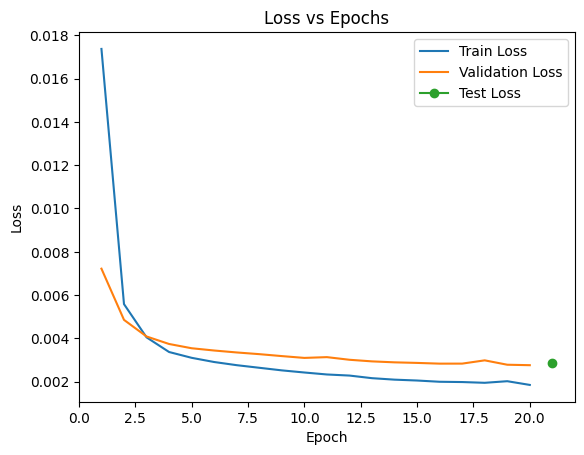

In [ ]:
# ——— Plot Loss vs Epochs ———
plt.figure()
plt.plot(range(1, len(train_losses)  + 1), train_losses,    label="Train Loss")
plt.plot(range(1, len(val_losses)    + 1), val_losses,      label="Validation Loss")
plt.plot(len(train_losses) + 1, avg_test_loss,              marker='o', label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()

The graph of training losses can be seen in the evaluation section but is included here for reference
#### Hyperparameter Justification
Learning Rate - Initially decided based on prior experience with deep learning models and then changed by factors of 10 until loss decreases steadily, forming the traditional curve seen with stable convergence.

Batch Size - A batch size of 64 was chosen initially as it gives a good balance of speed and stability. Larger batch sizes are not needed as, there is already a smooth curve with relativley short training times. Smaller batches will lead to less stable convergence.

Epochs - I chose to train for 30 epochs as that was a good starting point on early iterations of the model. This hasnt been changed as it hasn't needed to, the model achieves an SSIM greater than 0.9 within this range. The SSIM isn't  increasing much by epoch 30 so there is no need to train any longer than this